# Homework 6  - Logistic Regression without using any libraries. 
 
Student Name: Kyle Castillo

Student UT EID: kmc5794

---

Partner Name: Andre Sae

Partner UT EID:

---

Date Created: 10/6/2025

Date Last Modified:

---

Totoal Points 20. 



In [15]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [16]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task 1 - (4 points)
We want to use logistic regerssion to predict if a patient will have heart problems or not. The column "Target" in our datasets includes data about heart disease. If the patient had heart disease, the patient's "Target" value equals 1. Otherwise, "Target" equals 0.

Prepare your data set for predicting heart disease ("Target" column) by using 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 

Split your data into 80% traning data and 20% test data ***without*** using any libraries other than the ones imported above. You must do it manually.

* Do a maximum of **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher/lower. 
* **Visualize your error/costs over the iterations with a plot**.
* No need to add an y-intercept in this task. 

(**4 points** - 3 points for code, 1 point for cost visualization)

In [17]:
# selecting features
features = heart_df[["Age", "Sex", "Chol"]]
labels = (heart_df["Target"] == "Yes").astype(int)

# train/test split
split = .8

train = np.arange(0, round(features.shape[0] * split) + 1)
test = np.arange(train[-1] + 1, features.shape[0])

train_x = features.loc[train]
train_y = labels.loc[train]

test_x = features.loc[test]
test_y = labels.loc[test]

In [18]:
def sigmoid(w , x):
    z = x.dot(w)
    return (1   /    (1 + (np.exp(-z))) ).reshape(-1,1)

def cost(w, x, y):
    a = sigmoid(w,x)
    # a = np.clip(sigmoid(w, x), 1e-12, 1 - 1e-12)
    cost_val = (-1/len(y)) * np.sum((y *   np.log(a)) + ((1 - y) * (np.log(1-a))))
    return cost_val

def grad_descent(w,x,y,alpha=.1):
    # learning_rule
    a = sigmoid(w,x)
    gradient = (x.T.dot(a - y)) / len(y)

    # descending to new w
    new_w =  w.reshape(-1, 1) - alpha * gradient
    return new_w

In [19]:
w = np.zeros(train_x.shape[1]).reshape(3,)
x = train_x.to_numpy().reshape(-1,3)
y = train_y.to_numpy().reshape(-1,1)

cost_hist = np.array([])

iterations = 100
alpha = .0001

for i in range(iterations):
    cost_val = cost(w,x,y)
    cost_hist = np.append(cost_hist,cost_val)
    w = grad_descent(w,x,y,alpha)

    print(f"new cost: {cost_val}")

new cost: 0.6931471805599454
new cost: 0.690937353989315
new cost: 0.689754454233494
new cost: 0.6892111640846298
new cost: 0.6889237242659396
new cost: 0.6887788595637342
new cost: 0.6886975766897084
new cost: 0.6886496313487969
new cost: 0.6886173637129793
new cost: 0.6885930978744327
new cost: 0.6885727293599344
new cost: 0.6885543596649688
new cost: 0.6885370165823382
new cost: 0.6885202362555887
new cost: 0.6885037859370232
new cost: 0.6884875526248673
new cost: 0.6884714799506129
new cost: 0.688455540064014
new cost: 0.6884397188766984
new cost: 0.6884240091289613
new cost: 0.688408406894744
new cost: 0.6883929098887694
new cost: 0.6883775166349383
new cost: 0.6883622260539793
new cost: 0.6883470372658683
new cost: 0.688331949489009
new cost: 0.6883169619936712
new cost: 0.6883020740770468
new cost: 0.6882872850524806
new cost: 0.6882725942431362
new cost: 0.6882580009795999
new cost: 0.6882435045981843
new cost: 0.6882291044404342
new cost: 0.6882147998526235
new cost: 0.6882005

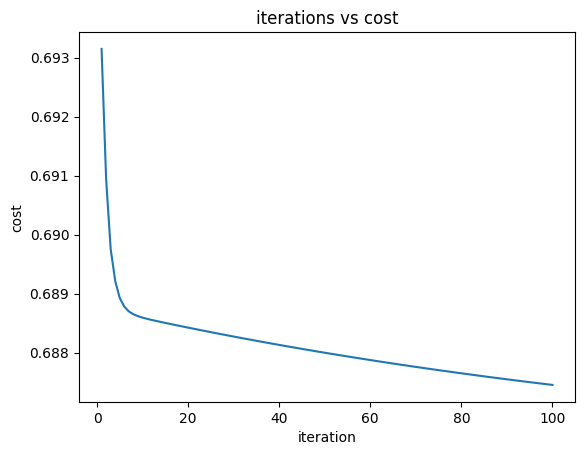

In [20]:
x = np.arange(1,101)
y = cost_hist

plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")

plt.show()

# Task 2 - (4 points)

Cacluate the Accuracy, Precision, Recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. 

You may use equations shown in lecture/slides/examples.

Calcuate the accuracy, precision, recall and F1 score of your logistic regression implementaion on the testing set. 
Print the results. (**4 points**)


In [21]:
x = test_x.to_numpy()
y_true = test_y.to_numpy()

y_prob = sigmoid(w, x)
y_pred = [1 if i >= .5 else 0  for i in y_prob]

results = pd.DataFrame({"y_true": y_true.flatten(),
    "y_pred": np.array(y_pred)})

results["tp"] = ((results["y_pred"] == 1) & (results["y_true"] == 1)).astype(int)
results["fp"] = ((results["y_pred"] == 1) & (results["y_true"] == 0)).astype(int)

results["tn"] = ((results["y_pred"] == 0) & (results["y_true"] == 0)).astype(int)
results["fn"] = ((results["y_pred"] == 0) & (results["y_true"] == 1)).astype(int)

accuracy = np.mean(results["y_pred"] == results["y_true"])
precision = results["tp"].sum() / (results["tp"].sum() + results["fp"].sum())
recall = results["tp"].sum() / (results["tp"].sum() + results["fn"].sum())
f1 = 2 * ((precision * recall) / (precision + recall))

print(f"accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1: {f1}")

accuracy: 0.4666666666666667
precision: 0.5
recall: 0.03125
f1: 0.058823529411764705


# Task 3 - (4 points)

Add a y-intercept and repeat the above tasks. Do you see any differences after adding the y-intercept?

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [22]:
def sigmoid_w_bias(b, w , x):
    z = x.dot(w) + b
    return (1   /    (1 + (np.exp((-1 * z)))) ).reshape(-1,1)

def cost_w_bias(b, w, x, y):
    # a = sigmoid_w_bias(b, w,x)
    a = np.clip(sigmoid_w_bias(b, w, x), 1e-12, 1 - 1e-12)
    cost_val = (-1/len(y)) * np.sum((y *   np.log(a)) + ((1 - y) * (np.log(1-a))))
    return cost_val

def grad_descent_w_bias(b, w,x,y,alpha=.1):
    # learning_rule
    a = sigmoid_w_bias(b, w,x)
    error = (a - y)
    w_gradient = (x.T.dot(error)) / len(y)
    b_gradient = np.mean(error)

    # descending to new w
    new_w = w - alpha * w_gradient
    new_b = b - alpha * b_gradient
    return new_b, new_w

In [23]:
x_unscaled = train_x.to_numpy()
mean = np.mean(x_unscaled, axis=0)
std = np.std(x_unscaled, axis=0)

x = (x_unscaled - mean) / std
b = 0
w = np.zeros((train_x.shape[1], 1))
y = train_y.to_numpy().reshape(-1,1)

cost_hist = np.array([])

iterations = 100
alpha = .1

for i in range(iterations):
    cost_val = cost_w_bias(b,w,x,y)
    cost_hist = np.append(cost_hist,cost_val)
    b, w = grad_descent_w_bias(b,w,x,y,alpha)

    print(f"new cost: {cost_val}")

new cost: 0.6931471805599454
new cost: 0.6890355706981565
new cost: 0.6851151770422077
new cost: 0.6813768498121549
new cost: 0.6778117863421752
new cost: 0.6744115357572882
new cost: 0.6711680003683171
new cost: 0.6680734342241139
new cost: 0.6651204392397398
new cost: 0.6623019592925619
new cost: 0.6596112726472456
new cost: 0.657041983037274
new cost: 0.6545880096963822
new cost: 0.6522435765993523
new cost: 0.6500032011388515
new cost: 0.6478616824340383
new cost: 0.645814089437947
new cost: 0.6438557489843838
new cost: 0.6419822338914026
new cost: 0.6401893512173077
new cost: 0.6384731307465138
new cost: 0.6368298137663506
new cost: 0.6352558421818392
new cost: 0.6337478480034371
new cost: 0.6323026432325202
new cost: 0.6309172101607892
new cost: 0.6295886920926185
new cost: 0.6283143844934869
new cost: 0.6270917265628156
new cost: 0.625918293225698
new cost: 0.6247917875349566
new cost: 0.6237100334726045
new cost: 0.6226709691380234
new cost: 0.6216726403088743
new cost: 0.62071

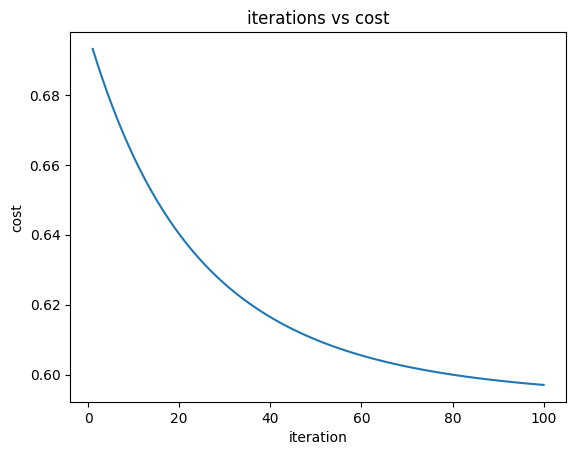

In [24]:
x = np.arange(1,iterations+1)
y = cost_hist

plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")

plt.show()

In [25]:
x_test_unscaled = test_x.to_numpy()
y_true = test_y.to_numpy().reshape(-1,1)

x_test_scaled = (x_test_unscaled - mean) / std

y_prob = sigmoid_w_bias(b, w, x_test_scaled)
y_pred = (y_prob >= 0.5).astype(int)

results = pd.DataFrame({
    "y_true": y_true.flatten(),
    "y_pred": y_pred.flatten()
})

results["tp"] = ((results["y_pred"] == 1) & (results["y_true"] == 1)).astype(int)
results["fp"] = ((results["y_pred"] == 1) & (results["y_true"] == 0)).astype(int)

results["tn"] = ((results["y_pred"] == 0) & (results["y_true"] == 0)).astype(int)
results["fn"] = ((results["y_pred"] == 0) & (results["y_true"] == 1)).astype(int)

accuracy = np.mean(results["y_pred"] == results["y_true"])
precision = results["tp"].sum() / (results["tp"].sum() + results["fp"].sum())
recall = results["tp"].sum() / (results["tp"].sum() + results["fn"].sum())
f1 = 2 * ((precision * recall) / (precision + recall))

print(f"accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1: {f1}")

accuracy: 0.6
precision: 0.6538461538461539
recall: 0.53125
f1: 0.5862068965517242


Scaling the features set each column to mean 0 and standard deviation 1, and adding a y-intercept let the model adjust the decision boundary. This kept the sigmoid inputs in a good range and helped the model learn properly. As a result, predictions were more balanced and accuracy and recall improved compared to the unscaled and no y-intercept version.

# Task 4 - Implement the Bold Driver   - (4 points)

Implement the bold driver into your gradient descent implementation, which lets us have a dynamic learning rate. Visualize the costs and print the accuracy/etc. metrics as before. Do not use a y-intercept this time.

Add a stop condition that stop the GD when the cost is not changing more than 0.001 between iterations. 
Describe the results. Did you stop earlier than 100 iterations?
(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)



In [26]:
w = np.zeros(train_x.shape[1]).reshape(3,)
x = train_x.to_numpy().reshape(-1,3)
y = train_y.to_numpy().reshape(-1,1)

cost_hist = np.array([])
prev_weight = None

iterations = 100
alpha = .0001
final_iterations = iterations

for i in range(iterations):
    cost_val = cost(w,x,y)
    w = grad_descent(w,x,y,alpha)

    if i != 0: 
        prev_cost_val = cost_hist[len(cost_hist) - 1]
        if prev_cost_val > cost_val: 
            alpha -= alpha * 0.025
        elif prev_cost_val + (10 ** -10) < cost_val:
            w = prev_weight
            alpha = alpha * 0.5
            
        if abs(cost_val - cost_hist[len(cost_hist) - 2]) < 0.001:
            final_iterations = i
            cost_hist = np.append(cost_hist,cost_val)
            print("Stopped at iteration # " + str(final_iterations))
            break
        

    cost_hist = np.append(cost_hist,cost_val)
    prev_weight = w 

    print(f"new cost: {cost_val}")
    
y_pred = np.matmul(w.T, x.T)
y_pred = np.transpose(y_pred)
y_pred = np.exp(y_pred) / (1 + np.exp(y_pred))
y_pred[y_pred < 0.5] = 0
y_pred[y_pred >= 0.5] = 1

y_pred

new cost: 0.6931471805599454
new cost: 0.690937353989315
new cost: 0.689754454233494
new cost: 0.6891505193687606
Stopped at iteration # 4


array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],

Text(0.5, 1.0, 'iterations vs cost')

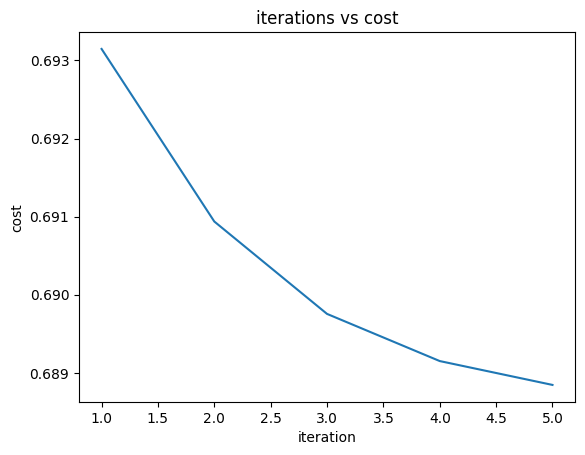

In [27]:
x = np.arange(1,len(cost_hist)+1)
y = cost_hist

plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")

# Task 5 - Implement the L2 norm regularization.  - (4 points)



Modify your Cost and gradient to implement the l2 norm regularization. Repeat the steps taken in prior tasks and describe your result.

 * Use a y-intercept.
 * Do a maximum of 100 iterations as before and report your accuracy, precision, recall and F1 score.
 * Optional: You can stop earlier, if the cost is not changing more than 0.001 between iterations.
 * Optional: You can use the bold driver, if you want. But a bold driver is not required to perform L2 norm regularizaiton.

(4 points - 2 for code, 1 for cost visualizaiton, 1 for description.)

In [28]:
def sigmoid_w_bias(b, w , x):
    z = x.dot(w) + b
    return (1   /    (1 + (np.exp((-1 * z)))) ).reshape(-1,1)

def cost_w_bias_l2(b, w, x, y, lam):
    # a = sigmoid_w_bias(b, w,x)
    a = np.clip(sigmoid_w_bias(b, w, x), 1e-12, 1 - 1e-12)
    loss = (-1/len(y)) * np.sum((y *   np.log(a)) + ((1 - y) * (np.log(1-a))))
    l2_penalty = (lam / (2 * len(y))) * np.sum(np.square(w))
    cost_val = loss + l2_penalty
    return cost_val

def grad_descent_w_bias_l2(b, w,x,y,lam,alpha=.1, ):
    # learning_rule
    a = sigmoid_w_bias(b, w, x)
    error = a - y

    w_gradient = (x.T.dot(error)) / len(y) + (lam / len(y)) * w
    b_gradient = np.mean(error)

    new_w = w - alpha * w_gradient
    new_b = b - alpha * b_gradient
    return new_b, new_w

In [29]:
x_unscaled = train_x.to_numpy()
mean = np.mean(x_unscaled, axis=0)
std = np.std(x_unscaled, axis=0)

x = (x_unscaled - mean) / std
b = 0
w = np.zeros((train_x.shape[1], 1))
y = train_y.to_numpy().reshape(-1,1)

cost_hist = np.array([])

iterations = 100
lam= 10
alpha = .1

for i in range(iterations):
    cost_val = cost_w_bias_l2(b,w,x,y,lam)
    cost_hist = np.append(cost_hist,cost_val)
    b, w = grad_descent_w_bias_l2(b,w,x,y,lam,alpha)

    print(f"new cost: {cost_val}")

new cost: 0.6931471805599454
new cost: 0.6890433989356282
new cost: 0.6851605675687332
new cost: 0.6814865325544281
new cost: 0.6780097236728142
new cost: 0.6747191454683683
new cost: 0.6716043649158233
new cost: 0.668655496324522
new cost: 0.6658631840732064
new cost: 0.6632185837038768
new cost: 0.6607133418396239
new cost: 0.6583395753292975
new cost: 0.6560898499630821
new cost: 0.6539571590485359
new cost: 0.6519349020869802
new cost: 0.6500168637456213
new cost: 0.6481971932814432
new cost: 0.6464703845385837
new cost: 0.6448312566112979
new cost: 0.6432749352393995
new cost: 0.641796834981806
new cost: 0.6403926421961045
new cost: 0.6390582988374853
new cost: 0.6377899870785538
new cost: 0.6365841147420537
new cost: 0.6354373015310925
new cost: 0.6343463660357209
new cost: 0.6333083134904315
new cost: 0.6323203242540483
new cost: 0.631379742981383
new cost: 0.6304840684547495
new cost: 0.629630944042788
new cost: 0.628818148753954
new cost: 0.6280435888523281
new cost: 0.6273052

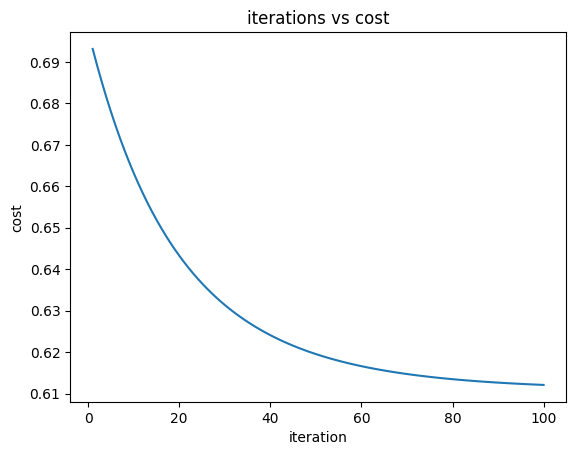

In [30]:
x = np.arange(1,iterations+1)
y = cost_hist

plt.plot(x,y)

plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("iterations vs cost")

plt.show()

In [31]:
x_test_unscaled = test_x.to_numpy()
y_true = test_y.to_numpy().reshape(-1,1)

x_test_scaled = (x_test_unscaled - mean) / std

y_prob = sigmoid_w_bias(b, w, x_test_scaled)
y_pred = (y_prob >= 0.5).astype(int)

results = pd.DataFrame({"y_true": y_true.flatten(),
    "y_pred": np.array(y_pred).flatten()})

results["tp"] = ((results["y_pred"] == 1) & (results["y_true"] == 1)).astype(int)
results["fp"] = ((results["y_pred"] == 1) & (results["y_true"] == 0)).astype(int)

results["tn"] = ((results["y_pred"] == 0) & (results["y_true"] == 0)).astype(int)
results["fn"] = ((results["y_pred"] == 0) & (results["y_true"] == 1)).astype(int)

accuracy = np.mean(results["y_pred"] == results["y_true"])
precision = results["tp"].sum() / (results["tp"].sum() + results["fp"].sum())
recall = results["tp"].sum() / (results["tp"].sum() + results["fn"].sum())
f1 = 2 * ((precision * recall) / (precision + recall))

print(f"accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1: {f1}")

# w's no lambda
# array([[0.49151999],
#        [0.61648032],
#        [0.21707886]])


# w's with lambda
# array([[0.49891395],
#       [0.62617623],
#       [0.22044241]])

accuracy: 0.6
precision: 0.6538461538461539
recall: 0.53125
f1: 0.5862068965517242


When lambda was added, the weights got a little smaller because regularization pushes them toward zero. This makes the model a bit less flexible, so the training error went up slightly. The tradeoff is that it can help the model generalize better on new data.